In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\adity\Downloads\Inteelipat course\OnlineRetail.csv", encoding='latin1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
df.shape

(541909, 8)

In [ ]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
df = df.dropna(subset=['CustomerID'])

In [6]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [7]:
df['Description'] = df['Description'].fillna('Unknown Product')

In [8]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [11]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [13]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [14]:
df[['Quantity','UnitPrice','Revenue']].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


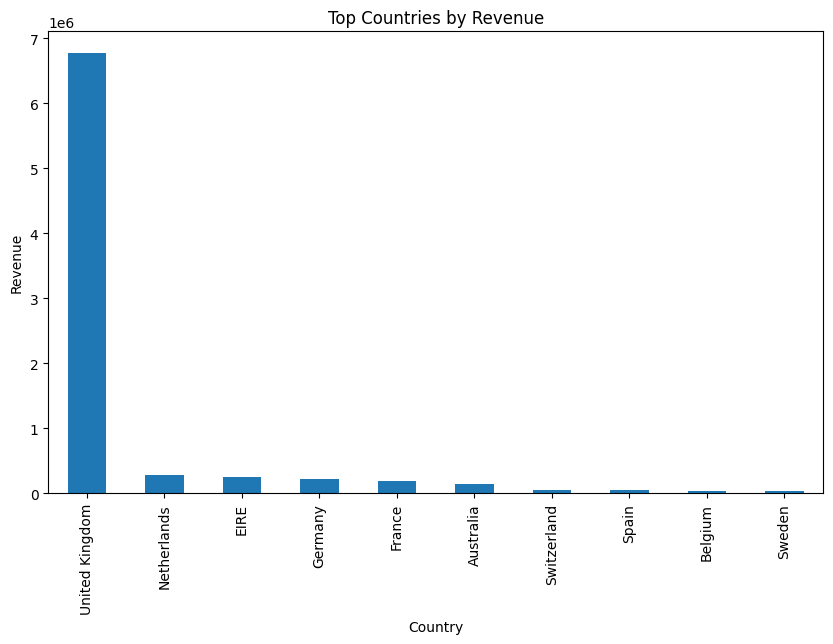

In [15]:
country_sales = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
country_sales.head(10).plot(kind='bar')
plt.title("Top Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.show()

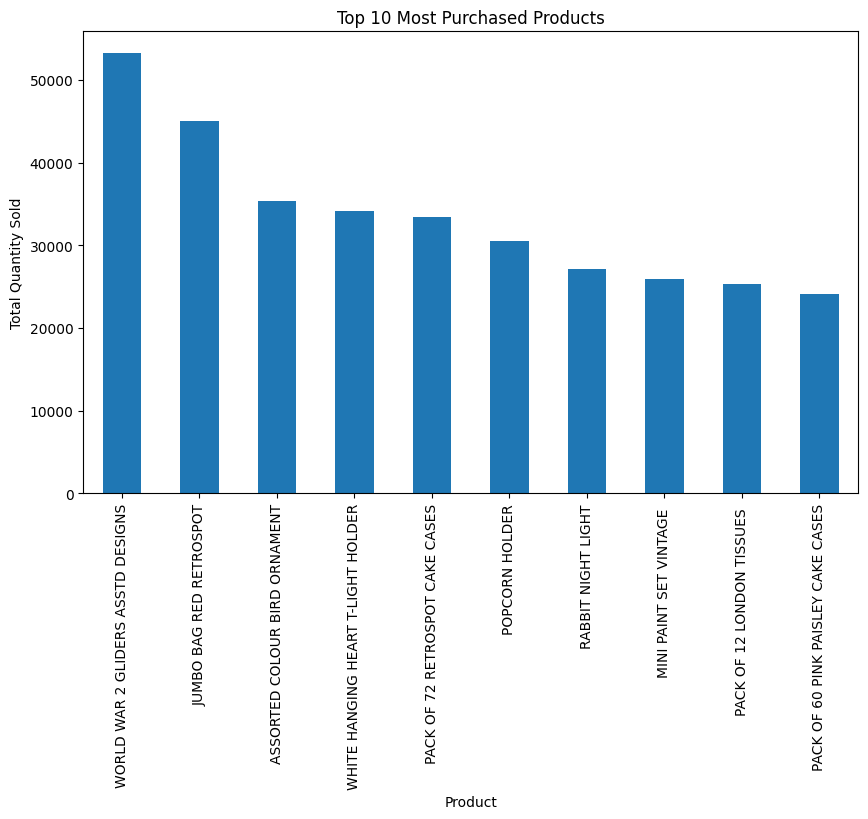

In [17]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
top_products.head(10).plot(kind='bar')
plt.title("Top 10 Most Purchased Products")
plt.xlabel("Product")
plt.ylabel("Total Quantity Sold")
plt.show()

In [19]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'count',
    'Revenue': 'sum'
})
rfm.columns = ['Recency','Frequency','Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

In [21]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,2,0.00,1
12347.0,2,182,4310.00,0
12348.0,75,31,1797.24,0
12349.0,19,73,1757.55,0
12350.0,310,17,334.40,1


In [22]:
rfm['Cluster'].value_counts()

Cluster
0    3258
1    1103
2       6
3       5
Name: count, dtype: int64

In [23]:
rfm.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,40.027931,105.034377,1994.059792
1,246.567543,27.770626,464.787073
2,1.666667,4821.500000,55039.933333
3,9.000000,1013.400000,192103.854000


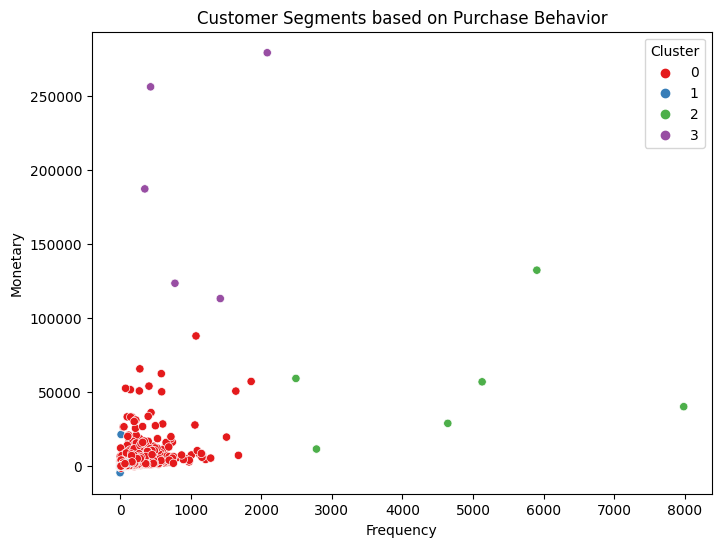

In [24]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    data=rfm,
    palette='Set1'
)
plt.title("Customer Segments based on Purchase Behavior")
plt.show()

In [25]:
top_customers = rfm.sort_values('Monetary', ascending=False).head(10)
top_customers

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
14646.0,2,2085,279489.02,3
18102.0,1,433,256438.49,3
17450.0,8,351,187482.17,3
14911.0,1,5903,132572.62,2
12415.0,24,778,123725.45,3
14156.0,10,1420,113384.14,3
17511.0,3,1076,88125.38,0
16684.0,4,281,65892.08,0
13694.0,4,585,62653.10,0


# Insight 1 — Revenue Concentration by Country

In [27]:
country_sales = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
country_sales.head(10)

Country
United Kingdom    6767873.394
Netherlands        284661.540
EIRE               250285.220
Germany            221698.210
France             196712.840
Australia          137077.270
Switzerland         55739.400
Spain               54774.580
Belgium             40910.960
Sweden              36595.910
Name: Revenue, dtype: float64

# Insight 2 — Top Selling Products

In [28]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False)
top_products.head(10)

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53215
JUMBO BAG RED RETROSPOT               45066
ASSORTED COLOUR BIRD ORNAMENT         35314
WHITE HANGING HEART T-LIGHT HOLDER    34147
PACK OF 72 RETROSPOT CAKE CASES       33409
POPCORN HOLDER                        30504
RABBIT NIGHT LIGHT                    27094
MINI PAINT SET VINTAGE                25880
PACK OF 12 LONDON TISSUES             25321
PACK OF 60 PINK PAISLEY CAKE CASES    24163
Name: Quantity, dtype: int64

# Insight 3 — Monthly Sales Trend (Seasonality)

<Axes: xlabel='Month'>

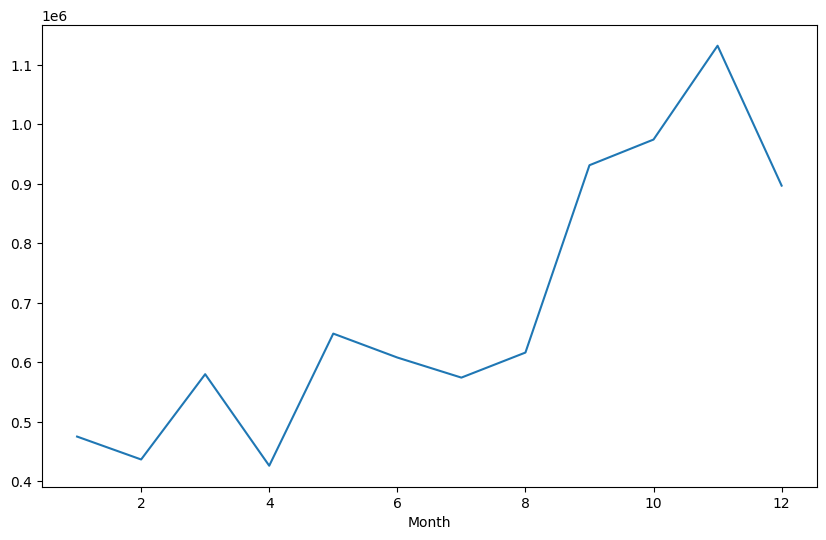

In [29]:
df['Month'] = df['InvoiceDate'].dt.month
monthly_sales = df.groupby('Month')['Revenue'].sum()
monthly_sales.plot(figsize=(10,6))

# Insight 4 — Customer Segmentation (RFM Clusters)

In [30]:
rfm.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,40.027931,105.034377,1994.059792
1,246.567543,27.770626,464.787073
2,1.666667,4821.500000,55039.933333
3,9.000000,1013.400000,192103.854000
